# Flight Delays — Starting Notebook

You will build a baseline model that predicts whether a US domestic
flight will arrive **15 or more minutes late** (`ArrDel15`). The
prediction is made shortly after departure, so actual departure delay
is known but the arrival outcome is not.

In [1]:
import os

import joblib
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd

from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    accuracy_score,
    classification_report,
    f1_score,
)
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

plt.style.use("seaborn-v0_8-whitegrid")
BLUE = "#1f6fb2"
ORANGE = "#e67e22"

## 1. Load the January flights

Run this notebook from its `CODE/` folder. The relative path below
reaches the shared course data directory at the repository root.

In [2]:
df = pd.read_csv("../../../../data/flight_delays_2025_01.csv")
df.head()

,Year,Quarter,Month,DayofMonth,DayOfWeek,FlightDate,Reporting_Airline,Flight_Number_Reporting_Airline,Origin,OriginCityName,...,Diverted,CRSElapsedTime,ActualElapsedTime,AirTime,Distance,CarrierDelay,WeatherDelay,NASDelay,SecurityDelay,LateAircraftDelay
0,2025,1,1,1,3,2025-01-01,AA,1,JFK,"New York, NY",...,0.0,381.0,377.0,345.0,2475.0,NaN,NaN,NaN,NaN,NaN
1,2025,1,1,2,4,2025-01-02,AA,1,JFK,"New York, NY",...,0.0,381.0,390.0,353.0,2475.0,NaN,NaN,NaN,NaN,NaN
2,2025,1,1,3,5,2025-01-03,AA,1,JFK,"New York, NY",...,0.0,381.0,371.0,347.0,2475.0,NaN,NaN,NaN,NaN,NaN
3,2025,1,1,4,6,2025-01-04,AA,1,JFK,"New York, NY",...,0.0,386.0,383.0,349.0,2475.0,NaN,NaN,NaN,NaN,NaN
4,2025,1,1,5,7,2025-01-05,AA,1,JFK,"New York, NY",...,0.0,381.0,378.0,347.0,2475.0,NaN,NaN,NaN,NaN,NaN


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 539747 entries, 0 to 539746
Data columns (total 40 columns):
 #   Column                           Non-Null Count   Dtype  
---  ------                           --------------   -----  
 0   Year                             539747 non-null  int64  
 1   Quarter                          539747 non-null  int64  
 2   Month                            539747 non-null  int64  
 3   DayofMonth                       539747 non-null  int64  
 4   DayOfWeek                        539747 non-null  int64  
 5   FlightDate                       539747 non-null  object 
 6   Reporting_Airline                539747 non-null  object 
 7   Flight_Number_Reporting_Airline  539747 non-null  int64  
 8   Origin                           539747 non-null  object 
 9   OriginCityName                   539747 non-null  object 
 10  OriginState                      539747 non-null  object 
 11  Dest                             539747 non-null  object 
 12  De

In [4]:
df.columns

Index(['Year', 'Quarter', 'Month', 'DayofMonth', 'DayOfWeek', 'FlightDate',
       'Reporting_Airline', 'Flight_Number_Reporting_Airline', 'Origin',
       'OriginCityName', 'OriginState', 'Dest', 'DestCityName', 'DestState',
       'CRSDepTime', 'DepTime', 'DepDelay', 'DepDelayMinutes', 'DepDel15',
       'TaxiOut', 'WheelsOff', 'WheelsOn', 'TaxiIn', 'CRSArrTime', 'ArrTime',
       'ArrDelay', 'ArrDelayMinutes', 'ArrDel15', 'Cancelled',
       'CancellationCode', 'Diverted', 'CRSElapsedTime', 'ActualElapsedTime',
       'AirTime', 'Distance', 'CarrierDelay', 'WeatherDelay', 'NASDelay',
       'SecurityDelay', 'LateAircraftDelay'],
      dtype='object')

## 2. Check data quality and the target

Before plotting relationships, check what can prevent a row from being
used for this prediction task: missing targets, cancelled or diverted
flights, duplicate rows, and heavily missing columns.

In [5]:
df.duplicated().sum()

np.int64(0)

In [6]:
df.isnull().mean()[df.isnull().mean() > 0].sort_values(ascending=False)

CancellationCode     0.969778
NASDelay             0.818193
WeatherDelay         0.818193
LateAircraftDelay    0.818193
CarrierDelay         0.818193
SecurityDelay        0.818193
ActualElapsedTime    0.032382
ArrDel15             0.032382
AirTime              0.032382
ArrDelay             0.032382
ArrDelayMinutes      0.032382
TaxiIn               0.030718
ArrTime              0.030718
WheelsOn             0.030718
WheelsOff            0.030064
TaxiOut              0.030064
DepDelayMinutes      0.029501
DepDel15             0.029501
DepDelay             0.029501
DepTime              0.029432
dtype: float64

In [7]:
print("Target distribution (including missing values):")
print(df["ArrDel15"].value_counts(dropna=False))

Target distribution (including missing values):
ArrDel15
0.0    424139
1.0     98130
NaN     17478
Name: count, dtype: int64


In [8]:
print(f"Cancelled flights: {int(df['Cancelled'].sum()):,}")
print(f"Diverted flights: {int(df['Diverted'].sum()):,}")

Cancelled flights: 16,312
Diverted flights: 1,166


In [9]:
print(f"Sum of Diverted and Cancelled flights: {int(df['Diverted'].sum() + df['Cancelled'].sum()):,}")

Sum of Diverted and Cancelled flights: 17,478


In [10]:
df[df["Diverted"] == 1][["Cancelled", "Diverted", "ArrDel15"]].head()

,Cancelled,Diverted,ArrDel15
53,0.0,1.0,NaN
119,0.0,1.0,NaN
224,0.0,1.0,NaN
489,0.0,1.0,NaN
729,0.0,1.0,NaN


In [11]:
df[(df["Diverted"] == 1) | (df["Cancelled"] == 1)]["ArrDel15"].isna().sum()

np.int64(17478)

**Exploration insight:** arrival-delay labels are missing mainly when a
flight never completed normally. Delay-cause columns are also mostly
empty because they are populated only for delayed flights. Filling every
missing value with zero would therefore mix different meanings.

## 3. Define the modeling cohort

Keep completed, non-diverted flights with a known target. Duplicate
removal is included even though this file currently has none. 

In [12]:
flights = (
    df.loc[
        df["Cancelled"].eq(0)
        & df["Diverted"].eq(0)
        & df["ArrDel15"].notna()
    ]
    .drop_duplicates()
    .copy()
)

In [14]:
# The scheduled departure hour is available at prediction time.

flights["scheduled_departure_hour"] = (
    flights["CRSDepTime"].floordiv(100).clip(0, 23).astype(int)
)

## 4. EDA — class balance

Start with the outcome the model must learn.

In [15]:
delayed_share = flights["ArrDel15"].mean()
print(f"Modeling rows: {len(flights):,}")
print(f"Delayed flights: {delayed_share:.1%}")

Modeling rows: 522,269
Delayed flights: 18.8%


**Cohort insight:** 522,269 flights remain and about 18.8% are delayed.
Because the classes are imbalanced, accuracy alone will not tell you
whether the model recognizes delayed flights; report F1 as well.

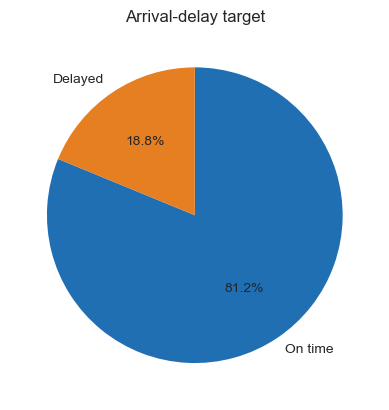

In [16]:
class_counts = flights["ArrDel15"].value_counts().sort_index()

plt.pie(class_counts, labels=["On time", "Delayed"],
        colors=[BLUE, ORANGE], autopct="%1.1f%%",
        startangle=90, counterclock=False)
plt.title("Arrival-delay target")
plt.show()

**EDA insight:** roughly four out of five completed flights arrive on
time. A model that always predicts “on time” would look respectable on
accuracy while being useless for finding delays.

## 5. EDA — delay rate by airline

Compare rates rather than raw delayed-flight counts so large carriers
do not automatically dominate the chart.

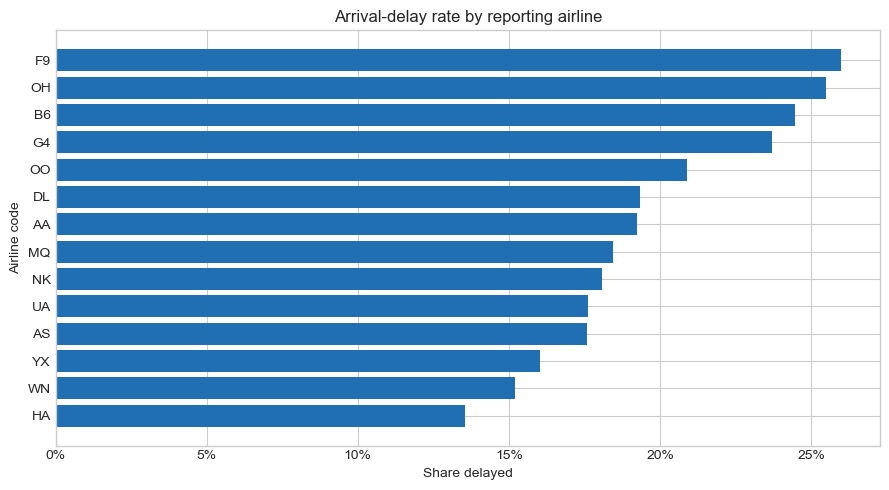

,delay_rate,flights
Reporting_Airline,,
HA,0.135,6540
WN,0.152,102120
YX,0.160,26683
AS,0.176,17847
UA,0.176,60668
NK,0.181,16946
MQ,0.184,20831
AA,0.192,72082
DL,0.193,74025


In [17]:
airline_delay = (
    flights.groupby("Reporting_Airline")["ArrDel15"]
    .agg(delay_rate="mean", flights="size")
    .sort_values("delay_rate")
)

fig, ax = plt.subplots(figsize=(9, 5))
ax.barh(airline_delay.index, airline_delay["delay_rate"], color=BLUE)
ax.set(
    title="Arrival-delay rate by reporting airline",
    xlabel="Share delayed",
    ylabel="Airline code",
)
ax.xaxis.set_major_formatter(lambda value, position: f"{value:.0%}")
plt.tight_layout()
plt.show()

airline_delay.round({"delay_rate": 3})

**EDA insight:** January delay rates range from about 13.5% for HA to
26.0% for F9. Airline carries signal, but this chart does not prove that
the carrier itself causes the difference; routes and schedules also
vary by carrier.

## 6. EDA — delay rate by scheduled departure hour

Very small overnight groups can produce unstable percentages, so plot
only hours with at least 1,000 flights.

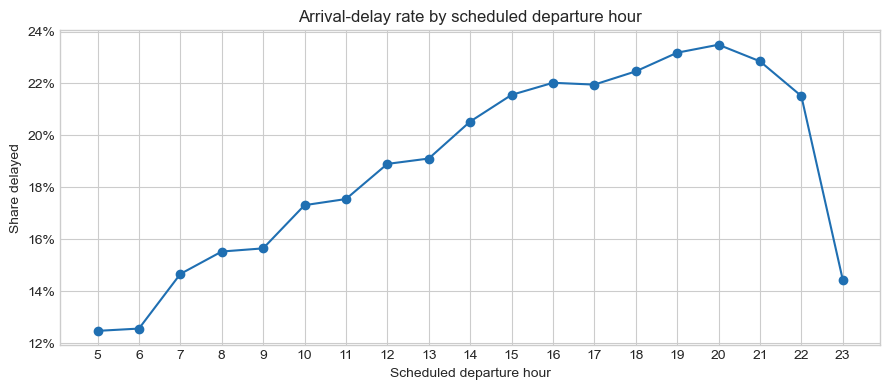

In [18]:
hourly_delay = flights.groupby("scheduled_departure_hour")["ArrDel15"].agg(
    delay_rate="mean",
    flights="size",
)
hourly_delay = hourly_delay.loc[hourly_delay["flights"] >= 1_000]

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(
    hourly_delay.index,
    hourly_delay["delay_rate"],
    marker="o",
    color=BLUE,
)
ax.set(
    title="Arrival-delay rate by scheduled departure hour",
    xlabel="Scheduled departure hour",
    ylabel="Share delayed",
    xticks=hourly_delay.index,
)
ax.yaxis.set_major_formatter(lambda value, position: f"{value:.0%}")
plt.tight_layout()
plt.show()

**EDA insight:** among well-represented hours, the delay rate rises from
roughly 12.5% around 05:00–06:00 to about 23.5% around 20:00. Delay risk
appears to accumulate across the operating day.

## 7. EDA — departure delay and arrival outcome

Departure delay is available because this prediction is made shortly
after departure. Bin it to make the relationship easy to read.

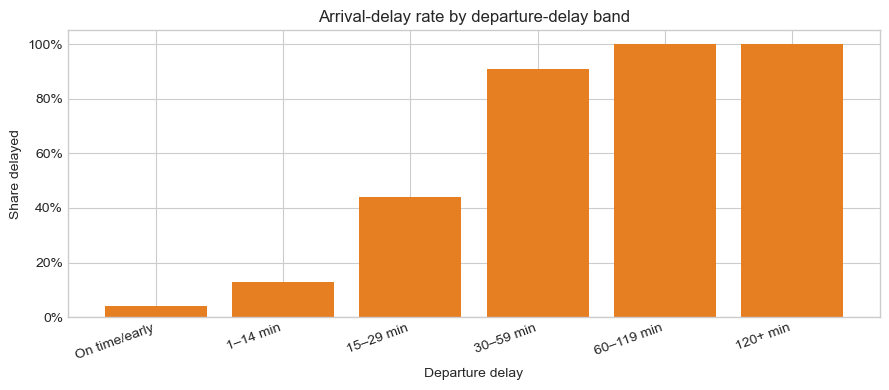

,arrival_delay_rate
departure_delay_band,
On time/early,0.040
1–14 min,0.130
15–29 min,0.440
30–59 min,0.907
60–119 min,0.999
120+ min,1.000


In [19]:
delay_bins = [-np.inf, 1, 15, 30, 60, 120, np.inf]
delay_labels = [
    "On time/early",
    "1–14 min",
    "15–29 min",
    "30–59 min",
    "60–119 min",
    "120+ min",
]
departure_delay_band = pd.cut(
    flights["DepDelay"],
    bins=delay_bins,
    labels=delay_labels,
    right=False,
)
delay_band_rate = (
    flights.assign(departure_delay_band=departure_delay_band)
    .groupby("departure_delay_band", observed=False)["ArrDel15"]
    .mean()
)

fig, ax = plt.subplots(figsize=(9, 4))
ax.bar(delay_band_rate.index, delay_band_rate, color=ORANGE)
ax.set(
    title="Arrival-delay rate by departure-delay band",
    xlabel="Departure delay",
    ylabel="Share delayed",
)
ax.yaxis.set_major_formatter(lambda value, position: f"{value:.0%}")
plt.xticks(rotation=20, ha="right")
plt.tight_layout()
plt.show()

delay_band_rate.to_frame("arrival_delay_rate").round(3)

**EDA insight:** only about 4.0% of flights leaving on time or early
arrive late, compared with about 44.0% for departures delayed 15–29
minutes and 90.7% for delays of 30–59 minutes. Departure delay is the
strongest obvious feature for this shortly-after-departure prediction.

## 8. Split raw features before preprocessing

Keep numeric and categorical columns separate. Split the raw rows now;
the preprocessing pipeline will learn medians, scales, and categories
from the training set only.

In [20]:
numeric_features = [
    "DepDelay",
    "Distance",
    "CRSElapsedTime",
    "scheduled_departure_hour",
    "DayOfWeek",
]
categorical_features = ["Reporting_Airline", "Origin", "Dest"]

X = flights[numeric_features + categorical_features]
y = flights["ArrDel15"].astype(int)

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y,
)

print(f"Training rows: {len(X_train):,}")
print(f"Test rows: {len(X_test):,}")

Training rows: 417,815
Test rows: 104,454


## 9. Build one preprocessing and model pipeline

Numeric columns receive median imputation and `StandardScaler`.
Categorical columns receive most-frequent imputation and
`OneHotEncoder`. `handle_unknown="ignore"` lets the fitted model accept
a carrier or airport category that was absent from the training split.

Logistic regression is a clear baseline for this transformed feature
space. Unlike a random forest, it benefits from scaled numeric inputs.

In [21]:
numeric_pipeline = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
    ]
)

categorical_pipeline = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore")),
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        ("numeric", numeric_pipeline, numeric_features),
        ("categorical", categorical_pipeline, categorical_features),
    ]
)

model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "classifier",
            LogisticRegression(
                max_iter=500,
                class_weight="balanced",
                random_state=42,
            ),
        ),
    ]
)

model

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('numeric',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['DepDelay', 'Distance',
                                                   'CRSElapsedTime',
                                                   'scheduled_departure_hour',
                                                   'DayOfWeek']),
                                                 ('categorical',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['Reporting_Airline',
                                                   'Origin', 'Dest'])])),
                ('classifier',
                 LogisticRegression(class_weight='balanced', max_iter=500,
                                    random_state=42))])

## 10. Train the baseline

Calling `fit` trains the imputers, scaler, encoder, and classifier in
the correct order using only the training rows.

In [22]:
model.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('numeric',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['DepDelay', 'Distance',
                                                   'CRSElapsedTime',
                                                   'scheduled_departure_hour',
                                                   'DayOfWeek']),
                                                 ('categorical',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['Reporting_Airline',
                                                   'Origin', 'Dest'])])),
                ('classifier',
                 LogisticRegression(class_weight='balanced', max_iter=500,
                                    random_state=42))])

## 11. Evaluate on untouched test rows

Report accuracy and F1, then inspect the confusion matrix and full
classification report.

accuracy: 0.8952
f1: 0.7415

              precision    recall  f1-score   support

           0     0.9520    0.9171    0.9342     84828
           1     0.6908    0.8003    0.7415     19626

    accuracy                         0.8952    104454
   macro avg     0.8214    0.8587    0.8379    104454
weighted avg     0.9029    0.8952    0.8980    104454



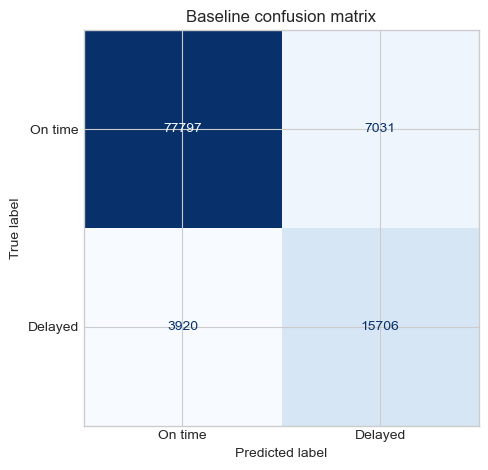

In [23]:
y_pred = model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print(f"accuracy: {accuracy:.4f}")
print(f"f1: {f1:.4f}")
print()
print(classification_report(y_test, y_pred, digits=4))

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred,
    display_labels=["On time", "Delayed"],
    cmap="Blues",
    colorbar=False,
)
plt.title("Baseline confusion matrix")
plt.tight_layout()
plt.show()

**Model insight:** class weighting trades some overall accuracy for
better recognition of delayed flights. F1 is the more useful headline
metric here because it combines precision and recall for the minority
delayed class.

In [24]:
prediction_preview = X_test.head(5).copy()
prediction_preview["delay_probability"] = model.predict_proba(
    prediction_preview
)[:, 1]
prediction_preview["prediction"] = model.predict(prediction_preview)
prediction_preview

,DepDelay,Distance,CRSElapsedTime,scheduled_departure_hour,DayOfWeek,Reporting_Airline,Origin,Dest,delay_probability,prediction
338100,-7.0,512.0,115.0,6,7,WN,BOI,OAK,0.054986,0
116472,49.0,1747.0,273.0,14,7,DL,ATL,LAS,0.994687,1
326046,21.0,990.0,175.0,19,2,WN,MCO,MDW,0.595765,1
102164,-1.0,1674.0,240.0,7,3,B6,BOS,SJU,0.512465,1
412701,121.0,1024.0,167.0,19,6,DL,SEA,DEN,0.999999,1


## 12. Save the complete fitted pipeline

Save preprocessing and the classifier together. The artifact can later
receive unencoded, unscaled feature rows with the same columns used
above. Creating `scheduled_departure_hour` from the raw CSV still lives
outside this fitted pipeline.

In [25]:
os.makedirs("models", exist_ok=True)
model_path = "models/model_2025_01.joblib"
joblib.dump(model, model_path)

print(f"Saved pipeline to {model_path}")
print(f"Artifact size: {os.path.getsize(model_path) / 1024:.1f} KiB")

Saved pipeline to models/model_2025_01.joblib
Artifact size: 17.5 KiB


## Notes to self

The ML workflow is sound enough for a baseline, but it is not yet an
operable ML system:

- data and artifact paths are hardcoded
- library versions are not recorded
- loading, cleaning, training, evaluation, and saving are trapped in notebook cells
- schema and preprocessing assumptions are not tested
- metrics are printed but no run history records their provenance.

These are five risks . The next lessons move this workflow into importable, testable, diagnosable project code.